In [1]:
import pandas as pd
from datetime import datetime, timedelta
from googleapiclient.discovery import build
import os
import re
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
# Load environment variables from .env file
load_dotenv()

# Retrieve API key from environment variables
YOUTUBE_DEVELOPER_KEY = os.getenv('YOUTUBE_DEVELOPER_KEY')

# Verify API key is loaded
if not YOUTUBE_DEVELOPER_KEY:
    raise ValueError("YouTube API key not found. Please create a .env file with YOUTUBE_API_KEY=")
    
youtube = build('youtube', 'v3', developerKey=YOUTUBE_DEVELOPER_KEY)

In [3]:
def get_channel(channel_name):
    return youtube.search().list(q=channel_name, type='channel', part='id,snippet').execute()['items'][0]

In [5]:
channel_name = 'GMM GRAMMY OFFICIAL'
CHANNEL_ID = get_channel(channel_name)['id']['channelId']
CHANNEL_ID

'UCG9gfnA5UDoLvz-tC9B-HKw'

In [7]:
# Function to get the channels stats
# It will also contain the upload playlist ID we can use to grab videos.
def get_channel_stats(youtube, channel_id):
    request = youtube.channels().list(
        part="snippet,contentDetails,statistics",
        id=channel_id
    )
    response = request.execute()
    
    return response['items']

In [9]:
# This will get us a list of videos from a playlist.
# Note a page of results has a max value of 50 so we will
# need to loop over our results with a pageToken

def get_video_list(youtube, upload_id):
    video_list = []
    request = youtube.playlistItems().list(
        part="snippet,contentDetails",
        playlistId=upload_id,
        maxResults=50
    )
    next_page = True
    while next_page:
        response = request.execute()
        data = response['items']

        for video in data:
            video_id = video['contentDetails']['videoId']
            if video_id not in video_list:
                video_list.append(video_id)

        # Do we have more pages?
        if 'nextPageToken' in response.keys():
            next_page = True
            request = youtube.playlistItems().list(
                part="snippet,contentDetails",
                playlistId=upload_id,
                pageToken=response['nextPageToken'],
                maxResults=50
            )
        else:
            next_page = False

    return video_list

In [11]:
# Once we have our video list we can pass it to this function to get details.
# Again we have a max of 50 at a time so we will use a for loop to break up our list. 

def get_video_details(youtube, video_list):
    stats_list=[]

    # Can only get 50 videos at a time.
    for i in range(0, len(video_list), 50):
        request= youtube.videos().list(
            part="snippet,contentDetails,statistics",
            id=video_list[i:i+50]
        )

        data = request.execute()
        for video in data['items']:
            video_id = video['id']  # Extract video_id            
            title=video['snippet']['title']
            published=video['snippet']['publishedAt']
            description=video['snippet']['description']
            # tag_count= len(video['snippet']['tags'])
            view_count=video['statistics'].get('viewCount',0)
            like_count=video['statistics'].get('likeCount',0)
            dislike_count=video['statistics'].get('dislikeCount',0)
            comment_count=video['statistics'].get('commentCount',0)
            # Include video_id in the dictionary
            stats_dict = dict(
                video_id=video_id,
                title=title,
                description=description,
                published=published,
                view_count=view_count,
                like_count=like_count,
                dislike_count=dislike_count,
                comment_count=comment_count
            )
            stats_list.append(stats_dict)

    return stats_list

In [13]:
channel_stats = get_channel_stats(youtube, CHANNEL_ID)

In [15]:
upload_id = channel_stats[0]['contentDetails']['relatedPlaylists']['uploads']
upload_id

'UUG9gfnA5UDoLvz-tC9B-HKw'

In [17]:
video_list = get_video_list(youtube, upload_id)
video_list[:10]

['sbMaiJPGCA0',
 'Q05jkCCr0Dk',
 'ECteP9QgZt0',
 'HZXq-89n05Q',
 'nvUpbuT2oQM',
 'DJr8087RpP0',
 'PtXTu30ipUc',
 '3pP7FkmNIdM',
 'bENWSMiaF9o',
 'azepYtYVVAQ']

In [19]:
video_data = get_video_details(youtube, video_list)
'Number 0f Videos: ' + str(len(video_data))

'Number 0f Videos: 19123'

In [21]:
video_data[:10]

[{'video_id': 'sbMaiJPGCA0',
  'title': 'วุ่นวาย อันดับ 1 : พวกเราเอง! #VIIS #Perses #GMMMusic',
  'description': 'วุ่นวาย อันดับ 1 : พวกเราเอง!\n\n#วุ่นวาย #25hours\n#VIIS #Perses\n#GMMMusic\n\n。。。。。。。。。。。。。。。。\n\n📲  ❛ SOCIAL GMM Grammy ❜\n\nhttps://www.instagram.com/gmmgrammy/\nhttps://www.facebook.com/GMMGRAMMYOFFICIAL\nhttps://twitter.com/GMMGRAMMY\nhttps://www.tiktok.com/@gmmgrammyofficial',
  'published': '2026-01-06T08:01:07Z',
  'view_count': '1422',
  'like_count': '34',
  'dislike_count': 0,
  'comment_count': '0'},
 {'video_id': 'Q05jkCCr0Dk',
  'title': 'รวมเพลงฮิตติด WOW VOL.1 l ความเงียบดังที่สุด, ภาวนา, คิด(แต่ไม่)ถึง [Same Page?], ฝนตกไหม [Longplay]',
  'description': "#GMMMusic #GMMGrammy #รวมเพลงฮิต #ดังเป็นล้านๆ #ฮิตในtiktok \n#เพลงไทย #ฮิตทุกที่ #เพื่อนเดินทาง #เพลงดังมาแรง #เพลงเพราะ #ฮิตทุกวัน\n#ฟังแล้วร้องตามได้ #เพลงแกรมมี่ #playlist #รวมเพลงน่าฟัง #เพลงฮิตติดWOW\n\n00:00 ความเงียบดังที่สุด - Getsunova\n04:21 ภาวนา - MEYOU\n07:00 คิด(แต่ไม่)ถึง [Same Page?] - Ti

In [23]:
df=pd.DataFrame(video_data)
df.drop(columns=['dislike_count'], inplace=True)
df['title_length'] = df['title'].str.len()
# Convert 'published' to datetime
df['published'] = pd.to_datetime(df['published'])
# Format 'published' to "%Y-%m-%d"
df['published'] = df['published'].dt.strftime('%Y-%m-%d')
df["view_count"] = pd.to_numeric(df["view_count"])
df["like_count"] = pd.to_numeric(df["like_count"])
df["comment_count"] = pd.to_numeric(df["comment_count"])
# reaction used later add up likes + dislikes + comments
df["reactions"] = df["like_count"] + df["comment_count"] + df["comment_count"]

df.shape

(19123, 9)

In [25]:
df.dtypes

video_id         object
title            object
description      object
published        object
view_count        int64
like_count        int64
comment_count     int64
title_length      int64
reactions         int64
dtype: object

In [27]:
# Select rows where the title contains "Animation Maker"
result = df
#result = df.query('title.str.lower().str.contains("abacus|deepsite|chatllm|n8n|react")', engine='python')
result.shape

(19123, 9)

In [29]:
cols = 'video_id title published view_count title_length'.split()

In [31]:
# Retrieve the maximum value from the title_length column
max_title_length = result['title_length'].max()
print("Maximum title length:", max_title_length)
# Set pandas column display width to the maximum title_length value
pd.set_option('display.max_colwidth', max_title_length)
result[cols].sort_values(by='published', ascending=False).head(10)

Maximum title length: 100


,video_id,title,published,view_count,title_length
0,sbMaiJPGCA0,วุ่นวาย อันดับ 1 : พวกเราเอง! #VIIS #Perses #GMMMusic,2026-01-06,1422,53
1,Q05jkCCr0Dk,"รวมเพลงฮิตติด WOW VOL.1 l ความเงียบดังที่สุด, ภาวนา, คิด(แต่ไม่)ถึง [Same Page?], ฝนตกไหม [Longp...",2026-01-06,1266,100
2,ECteP9QgZt0,"รวมเพลงน่าฟัง ที่เปิดดัง ๆ ในออฟฟิศ l เหนื่อยไหม, ไม่ยอมหมดหวัง, โปรดส่งใครมารักฉันที [Longplay]",2026-01-05,2391,96
3,HZXq-89n05Q,งานรวมตัวคนมีพิรุธแห่งปี... 🙂‍↔️ #PondPhuwin #FourthNattawat #GMMMusic,2026-01-05,12107,70
4,nvUpbuT2oQM,พรุ่งนี้วันจันทร์ ตั้งสติ ก่อนสตาร์ท 😭 #ตั้งสติ #GMMMusic,2026-01-04,24555,57
5,DJr8087RpP0,"รวมเพลงฮิตยุค 2000 ฟังแล้วร้องตามได้ Vol.2 l โอ้ละหนอ...My Love, อยากร้องดังดัง, คนใจง่าย [Longp...",2026-01-04,2626,100
6,PtXTu30ipUc,"รวมฮิต เพลงนี้เต้นกันเป็นแก๊ง Vol.2 l คนใจง่าย, คนใจง่าย, มืดตึ๊ดตื๋อ, ก็ใครมันจะไปรู้ล่ะ [Longp...",2026-01-03,3526,100
7,3pP7FkmNIdM,เทสที่สร้าง vs ร่างที่เป็น 😂 #คนแพ้ที่ไม่มีน้ำตา #เบิร์ดธงไชย #Perses #GMMMusic,2026-01-03,16761,79
8,bENWSMiaF9o,"รวมฮิต เพลงนี้เต้นกันเป็นแก๊ง Vol.1 l โอ้ละหนอ...My Love, อยากร้องดังดัง, ผีเสื้อราตรี [Longplay]",2026-01-02,3145,97
9,azepYtYVVAQ,ปีใหม่นี้ขอให้เฮง เฮง เฮง ทั้งปี 💸 #เฮงเฮงเฮง #CHINADOLLS #GMMMusic,2026-01-02,22525,67


In [33]:
# Just use this - it should work
csv_name = channel_name + '.csv'
df.to_csv(csv_name, encoding='utf-8-sig', index=False)

# Display results
print(f"✅ File saved: {csv_name}")
print(f"📊 Showing 10 most recent videos:")
display(df.sort_values(by="published", ascending=False).head(10))

✅ File saved: GMM GRAMMY OFFICIAL.csv
📊 Showing 10 most recent videos:


,video_id,title,description,published,view_count,like_count,comment_count,title_length,reactions
0,sbMaiJPGCA0,วุ่นวาย อันดับ 1 : พวกเราเอง! #VIIS #Perses #GMMMusic,วุ่นวาย อันดับ 1 : พวกเราเอง!\n\n#วุ่นวาย #25hours\n#VIIS #Perses\n#GMMMusic\n\n。。。。。。。。。。。。。。。。...,2026-01-06,1422,34,0,53,34
1,Q05jkCCr0Dk,"รวมเพลงฮิตติด WOW VOL.1 l ความเงียบดังที่สุด, ภาวนา, คิด(แต่ไม่)ถึง [Same Page?], ฝนตกไหม [Longp...",#GMMMusic #GMMGrammy #รวมเพลงฮิต #ดังเป็นล้านๆ #ฮิตในtiktok \n#เพลงไทย #ฮิตทุกที่ #เพื่อนเดินทาง...,2026-01-06,1266,26,1,100,28
2,ECteP9QgZt0,"รวมเพลงน่าฟัง ที่เปิดดัง ๆ ในออฟฟิศ l เหนื่อยไหม, ไม่ยอมหมดหวัง, โปรดส่งใครมารักฉันที [Longplay]",#GMMMusic #GMMGrammy #รวมเพลงฮิต #ดังเป็นล้านๆ #ฮิตในtiktok \n#เพลงไทย #ฮิตทุกที่ #เพื่อนเดินทาง...,2026-01-05,2391,47,2,96,51
3,HZXq-89n05Q,งานรวมตัวคนมีพิรุธแห่งปี... 🙂‍↔️ #PondPhuwin #FourthNattawat #GMMMusic,งานรวมตัวคนมีพิรุธแห่งปี... 🙂‍↔️\n\n#จังหวะหัวใจ #PondPhuwin #FourthNattawat\n#GMMMusic\n\n。。。。。...,2026-01-05,12107,134,2,70,138
4,nvUpbuT2oQM,พรุ่งนี้วันจันทร์ ตั้งสติ ก่อนสตาร์ท 😭 #ตั้งสติ #GMMMusic,"พรุ่งนี้วันจันทร์ ตั้งสติ ก่อนสตาร์ท 😭\n\nตั้งสติ - ศิริพร อำไพพงษ์ , เวียง นฤมล , ปลาย กนกพร , ...",2026-01-04,24555,186,5,57,196
5,DJr8087RpP0,"รวมเพลงฮิตยุค 2000 ฟังแล้วร้องตามได้ Vol.2 l โอ้ละหนอ...My Love, อยากร้องดังดัง, คนใจง่าย [Longp...",#GMMMusic #GMMGrammy #รวมเพลงฮิต #ดังเป็นล้านๆ #ฮิตในtiktok \n#เพลงไทย #ฮิตทุกที่ #เพื่อนเดินทาง...,2026-01-04,2626,64,3,100,70
6,PtXTu30ipUc,"รวมฮิต เพลงนี้เต้นกันเป็นแก๊ง Vol.2 l คนใจง่าย, คนใจง่าย, มืดตึ๊ดตื๋อ, ก็ใครมันจะไปรู้ล่ะ [Longp...",#GMMMusic #GMMGrammy #รวมเพลงฮิต #ดังเป็นล้านๆ #ฮิตในtiktok \n#เพลงไทย #ฮิตทุกที่ #เพื่อนเดินทาง...,2026-01-03,3526,52,4,100,60
7,3pP7FkmNIdM,เทสที่สร้าง vs ร่างที่เป็น 😂 #คนแพ้ที่ไม่มีน้ำตา #เบิร์ดธงไชย #Perses #GMMMusic,เทสที่สร้าง vs ร่างที่เป็น 😂\n\n#คนแพ้ที่ไม่มีน้ำตา #เบิร์ดธงไชย \n#Perses #GMMMusic\n\n。。。。。。。。...,2026-01-03,16761,141,3,79,147
8,bENWSMiaF9o,"รวมฮิต เพลงนี้เต้นกันเป็นแก๊ง Vol.1 l โอ้ละหนอ...My Love, อยากร้องดังดัง, ผีเสื้อราตรี [Longplay]",#GMMMusic #GMMGrammy #รวมเพลงฮิต #ดังเป็นล้านๆ #ฮิตในtiktok \n#เพลงไทย #ฮิตทุกที่ #เพื่อนเดินทาง...,2026-01-02,3145,54,2,97,58
9,azepYtYVVAQ,ปีใหม่นี้ขอให้เฮง เฮง เฮง ทั้งปี 💸 #เฮงเฮงเฮง #CHINADOLLS #GMMMusic,ปีใหม่นี้ขอให้เฮง เฮง เฮง ทั้งปี 💸\n\n#เฮงเฮงเฮง #CHINADOLLS\n#GMMMusic \n\n。。。。。。。。。。。。。。。。\n\n...,2026-01-02,22525,194,2,67,198


In [35]:
df_highest_views = result.nlargest(10, 'view_count')
df_highest_views['title'] = df_highest_views['title'].str[:40]
df_highest_views['view_count_hundreds'] = df_highest_views['view_count'] / 30
df_highest_views

,video_id,title,description,published,view_count,like_count,comment_count,title_length,reactions,view_count_hundreds
15642,GYpzzbVRrsk,PLEASE - Atom ชนกันต์【OFFICIAL MV 】,#Please #ATOMชนกันต์ \n#WhiteMusicRecord #GMMGrammy #GMMMusic #อะตอมชนกันต์ \n\nPlease - ATOM ชน...,2015-01-29,325142409,740068,13808,35,767684,1.083808e+07
17510,CKDwsFbq1_c,ขอใจเธอแลกเบอร์โทร - หญิงลี ศรีจุมพล (Yo,#ขอใจเธอแลกเบอร์โทร #หญิงลีศรีจุมพล #แกรมมี่โกลด์ #gmmmusic \n#GMMGrammy #grammygoldofficial #เพ...,2013-01-23,262573998,620144,35921,77,691986,8.752467e+06
15764,2dSGCzeuPlA,ซมซาน - LOSO【OFFICIAL MV】,#ซมซาน #เสกโลโซ #LOSO #GMMMusic \n#gmmgrammy #เพลงฮิต \n\nDigital Download : *123 1000082 3\niTu...,2014-12-24,247943589,743144,25387,26,793918,8.264786e+06
11455,9Ic6PWwTU8g,[100x100] ให้นานกว่าที่เคย (Collab Versi,#ให้นานกว่าที่เคย #KLEAR #ไผ่พงศธร #gmmmusic \n\nให้นานกว่าที่เคย (Collab Version) - KLEAR x ไผ่...,2019-06-05,238446808,807684,20688,77,849060,7.948227e+06
13743,zCLZL-RV1tY,เธอมีฉัน ฉันมีใคร - DA ENDORPHINE【OFFICI,#เธอมีฉันฉันมีใคร #DAENDORPHINE #ดาเอ็นโดรฟิน\n#GMMMusic #GMMGrammy #เพลงฮิต \n\n\nเมื่อฉันเหงา ...,2016-07-11,230021188,504225,19426,46,543077,7.667373e+06
15414,eeZQG86uhc8,ความลับในใจ - สิบล้อ【OFFICIAL MV】,#ความลับในใจ #สิบล้อ #GMMMusic\n\nDigital Download :*123 1000020 3\niTunes Download : http://goo...,2015-03-11,210132948,449686,11832,33,473350,7.004432e+06
16366,krk9TTf_Ez8,คิดถึงฉันไหมเวลาที่เธอ - TAXI 【OFFICIAL,#คิดถึงฉันไหมเวลาที่เธอ #TAXI \n#GMMMusic #gmmgrammy \n\nชื่อเพลง : คิดถึงฉันไหมเวลาที่เธอ\nศิ...,2014-09-20,205278835,705610,20983,43,747576,6.842628e+06
11821,qSvheEoBr4A,ไม่ไหวบอกไหว - BOY PEACEMAKER [MUSIC VID,"#ไม่ไหวบอกไหว #BOYPEACEMAKER #บอยพีชเมกเกอร์\n#GMMMusic #GMMGrammy #เพลงดัง #เพลงฮิต \n\n""เธอรู้...",2019-01-30,204706575,1047084,35823,43,1118730,6.823552e+06
16136,ds6r91puZGU,ทั้งที่ผิดก็ยังรัก - AB normal 【OFFICIAL,#ทั้งที่ผิดก็ยังรัก #ABnormal #genierecords \n#GMMMusic #GMMGrammy\n\nทั้งที่ผิดก็ยังรัก - AB no...,2014-10-16,194489610,382712,11724,44,406160,6.482987e+06
17648,WlY25SbEHFo,ฉันกำลังเป็นตัวแทนของใครหรือเปล่า - พี ส,#ฉันกำลังเป็นตัวแทนของใครหรือเปล่า #พีสะเดิด\n#GMMMusic #GMMGrammy\n\nDigital Download : *123 70...,2012-10-28,194169079,396572,12872,59,422316,6.472303e+06


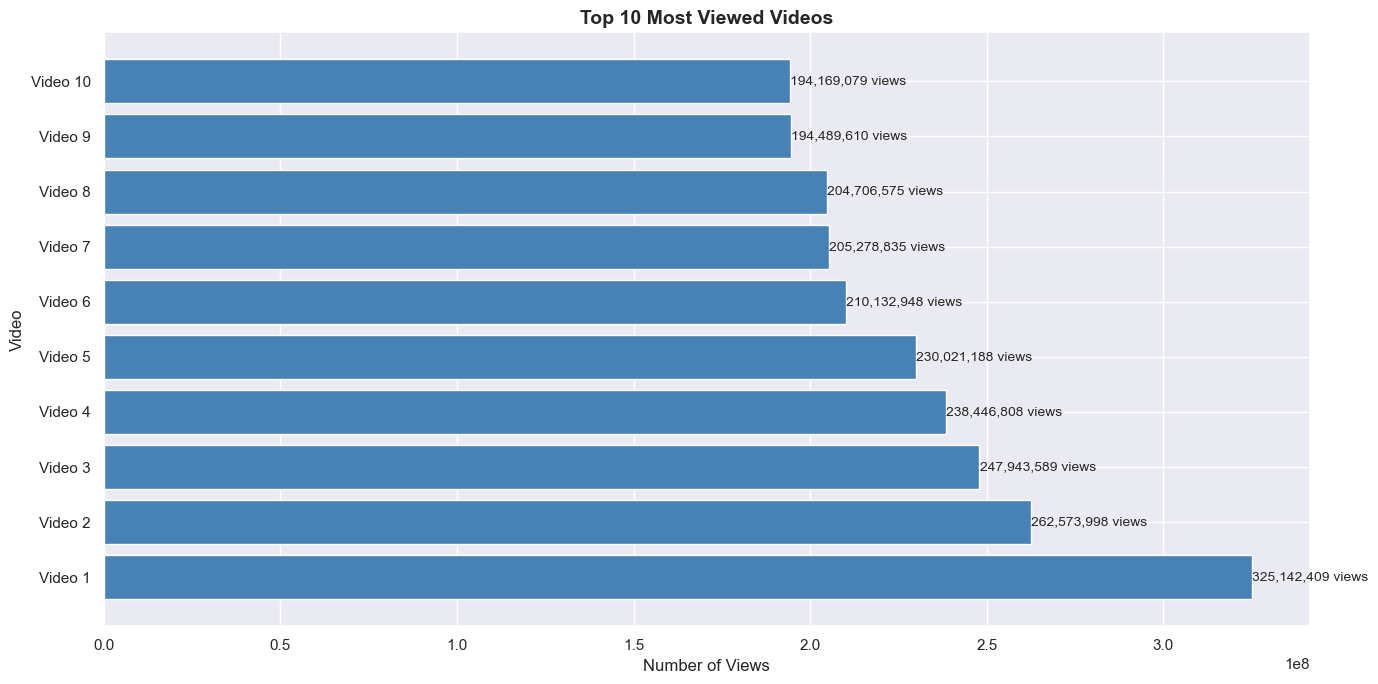


📊 **TOP 10 MOST VIEWED VIDEOS**
Rank   Video ID     Views        Published    Likes    Comments  
----------------------------------------------------------------------------------------------------
1      GYpzzbVRrsk  325,142,409  2015-01-29   740,068  13,808    
2      CKDwsFbq1_c  262,573,998  2013-01-23   620,144  35,921    
3      2dSGCzeuPlA  247,943,589  2014-12-24   743,144  25,387    
4      9Ic6PWwTU8g  238,446,808  2019-06-05   807,684  20,688    
5      zCLZL-RV1tY  230,021,188  2016-07-11   504,225  19,426    
6      eeZQG86uhc8  210,132,948  2015-03-11   449,686  11,832    
7      krk9TTf_Ez8  205,278,835  2014-09-20   705,610  20,983    
8      qSvheEoBr4A  204,706,575  2019-01-30   1,047,084 35,823    
9      ds6r91puZGU  194,489,610  2014-10-16   382,712  11,724    
10     WlY25SbEHFo  194,169,079  2012-10-28   396,572  12,872    

📈 **Total views for top 5: 2,312,905,039**


In [37]:
# SIMPLE SOLUTION - No Thai characters at all
sns.set(rc={'figure.figsize':(16,8)})

# Create plot with video numbers instead of titles
df_plot = df_highest_views.copy()
df_plot['video_number'] = [f'Video {i+1}' for i in range(len(df_plot))]

# Create bar plot
plt.figure(figsize=(14, 7))
bars = plt.barh(df_plot['video_number'], df_plot['view_count'], color='steelblue')
plt.xlabel('Number of Views', fontsize=12)
plt.ylabel('Video', fontsize=12)
plt.title('Top 10 Most Viewed Videos', fontsize=14, fontweight='bold')

# Add value labels
for bar, views in zip(bars, df_plot['view_count']):
    width = bar.get_width()
    plt.text(width + 5000, bar.get_y() + bar.get_height()/2, 
             f'{views:,} views', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Create a markdown table for the console
print("\n📊 **TOP 10 MOST VIEWED VIDEOS**")
print("="*100)
print(f"{'Rank':<6} {'Video ID':<12} {'Views':<12} {'Published':<12} {'Likes':<8} {'Comments':<10}")
print("-"*100)

for i, (_, row) in enumerate(df_highest_views.iterrows()):
    print(f"{i+1:<6} {row['video_id']:<12} {row['view_count']:<12,} {row['published']:<12} {row['like_count']:<8,} {row['comment_count']:<10,}")

print("="*100)
print(f"\n📈 **Total views for top 5: {df_highest_views['view_count'].sum():,}**")

In [45]:
colt = 'video_id title published view_count'.split()
output_file = channel_name + '.csv'
df_highest_views[colt].to_csv(output_file, index=None)
df_highest_views.head(10)[colt].sort_values(by="view_count",ascending=False)

,video_id,title,published,view_count
15642,GYpzzbVRrsk,PLEASE - Atom ชนกันต์【OFFICIAL MV 】,2015-01-29,325142409
17510,CKDwsFbq1_c,ขอใจเธอแลกเบอร์โทร - หญิงลี ศรีจุมพล (Yo,2013-01-23,262573998
15764,2dSGCzeuPlA,ซมซาน - LOSO【OFFICIAL MV】,2014-12-24,247943589
11455,9Ic6PWwTU8g,[100x100] ให้นานกว่าที่เคย (Collab Versi,2019-06-05,238446808
13743,zCLZL-RV1tY,เธอมีฉัน ฉันมีใคร - DA ENDORPHINE【OFFICI,2016-07-11,230021188
15414,eeZQG86uhc8,ความลับในใจ - สิบล้อ【OFFICIAL MV】,2015-03-11,210132948
16366,krk9TTf_Ez8,คิดถึงฉันไหมเวลาที่เธอ - TAXI 【OFFICIAL,2014-09-20,205278835
11821,qSvheEoBr4A,ไม่ไหวบอกไหว - BOY PEACEMAKER [MUSIC VID,2019-01-30,204706575
16136,ds6r91puZGU,ทั้งที่ผิดก็ยังรัก - AB normal 【OFFICIAL,2014-10-16,194489610
17648,WlY25SbEHFo,ฉันกำลังเป็นตัวแทนของใครหรือเปล่า - พี ส,2012-10-28,194169079


In [47]:
# Get the user's home directory
user_path = os.path.expanduser('~')
# Get the current working directory
current_path = os.getcwd()
# Derive the base directory (base_dir) by removing the last folder ('Daily')
base_path = os.path.dirname(current_path)
#C:\Users\PC1\OneDrive\A5\Excel
xsl_path = os.path.join(base_path, "Excel")

In [49]:
print("User path:", user_path)
print(f"Current path: {current_path}")
print(f"Base path: {base_path}")
print(f"Excel path (xsl_path): {xsl_path}")

User path: C:\Users\PC1
Current path: C:\Users\PC1\OneDrive\A4\YouTube
Base path: C:\Users\PC1\OneDrive\A4
Excel path (xsl_path): C:\Users\PC1\OneDrive\A4\Excel


In [51]:
xsl_file = channel_name + '.xlsx'
xsl_file = os.path.join(xsl_path, xsl_file)
xsl_file

'C:\\Users\\PC1\\OneDrive\\A4\\Excel\\GMM GRAMMY OFFICIAL.xlsx'

In [53]:
colt = 'video_id title published view_count read'.split()
df_highest_views['read'] = 'N'
df_highest_views[colt].to_excel(xsl_file, index=False)